# 手写数字分类器

In [1]:
# 环境准备
# %pip install torch torchvision matplotlib numpy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 定义模型

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 13 * 13, 10)
        )
    def forward(self, x):
        return self.conv(x)

In [ ]:
# 导入数据
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
# (input - mean)/standard
train_loader = DataLoader(datasets.MNIST('./data', train=True, download=True, transform=transform), batch_size=64, shuffle=True)

# 方法选择
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

100.0%
100.0%
100.0%
100.0%


In [7]:
# train！

print(f"开始在 {device} 上训练...")
losses = []

model.train()
for batch_idx, (data, target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device)
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output, target)
    losses.append(loss.item())
    loss.backward()
    optimizer.step()
    
    if batch_idx % 100 == 0:
        print(f"process: [{batch_idx * len(data)}/60000] \t loss: {loss.item():.4f}")

开始在 cpu 上训练...
process: [0/60000] 	 loss: 0.0774
process: [6400/60000] 	 loss: 0.0547
process: [12800/60000] 	 loss: 0.1809
process: [19200/60000] 	 loss: 0.0308
process: [25600/60000] 	 loss: 0.1712
process: [32000/60000] 	 loss: 0.0073
process: [38400/60000] 	 loss: 0.1764
process: [44800/60000] 	 loss: 0.0562
process: [51200/60000] 	 loss: 0.0982
process: [57600/60000] 	 loss: 0.1145


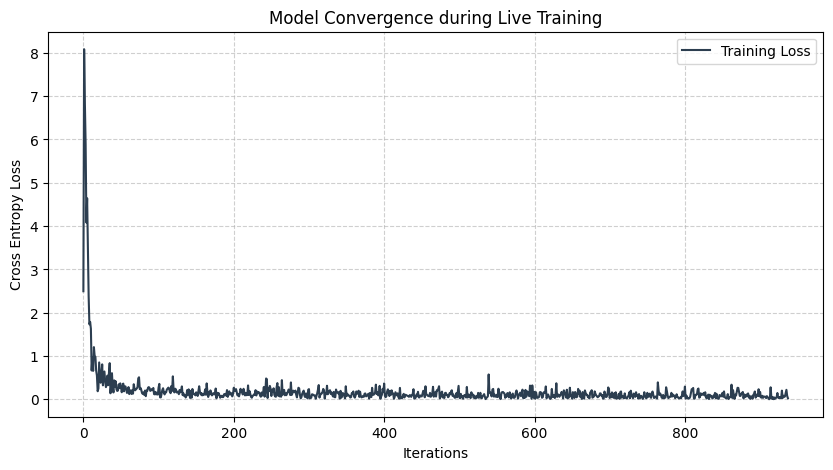

In [5]:
# 折线图可视化

plt.figure(figsize=(10, 5))
plt.plot(losses, label='Training Loss', color='#2c3e50')
plt.title('Model Convergence during Live Training')
plt.xlabel('Iterations')
plt.ylabel('Cross Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

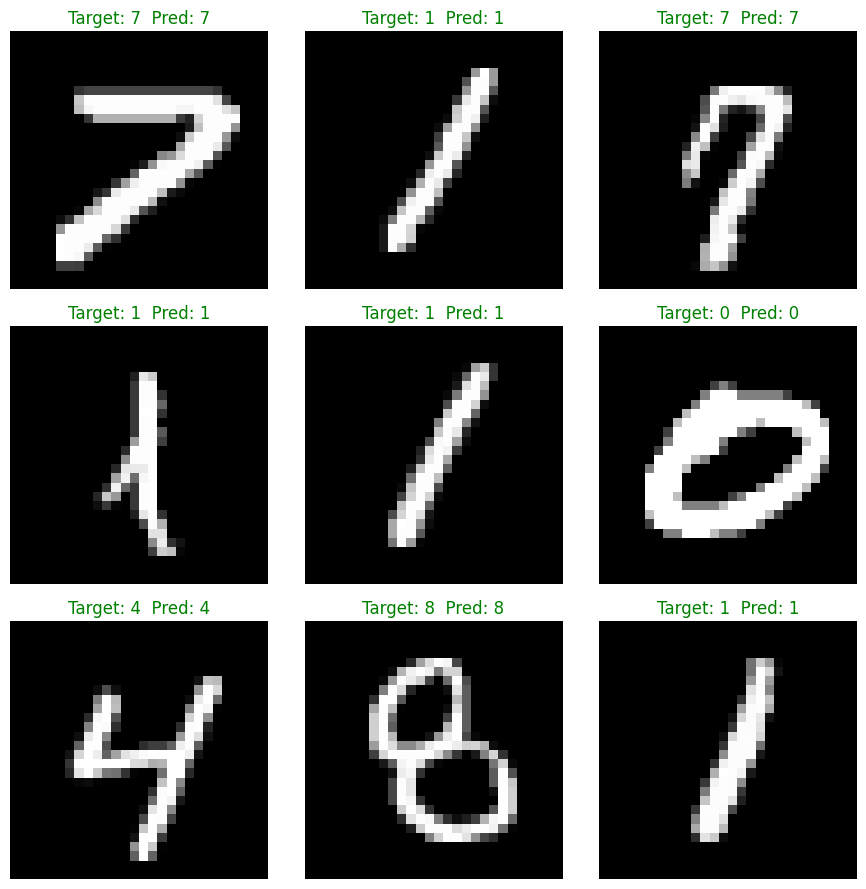

In [6]:
# 设置模型为评估模式（避免dropout）
model.eval()

# 获取一批测试数据
test_loader = DataLoader(datasets.MNIST('./data', train=False, transform=transform), batch_size=9, shuffle=True)
data, target = next(iter(test_loader))
output = model(data.to(device))
pred = output.argmax(dim=1, keepdim=True)

# 绘图展示
plt.figure(figsize=(9, 9))
for i in range(9):
    plt.subplot(3, 3, i+1)
    img = data[i].numpy().squeeze()
    plt.imshow(img, cmap='gray')
    
    # 如果预测正确显示绿色，错误显示红色
    color = 'green' if pred[i].item() == target[i].item() else 'red'
    plt.title(f"Target: {target[i].item()}  Pred: {pred[i].item()}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()